# Fake Review Detection using Machine Learning

## Import Libraries

In [2]:
import pandas as pd

## Load Dataset

In [3]:
df = pd.read_csv("../data/fake reviews dataset.csv")

## Exploratory Data Analysis (EDA)

In [4]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  str    
 1   rating    40432 non-null  float64
 2   label     40432 non-null  str    
 3   text_     40432 non-null  str    
dtypes: float64(1), str(3)
memory usage: 15.5 MB


In [6]:
df.columns

Index(['category', 'rating', 'label', 'text_'], dtype='str')

In [7]:
df["label"].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

In [8]:
df["label"].unique()

<ArrowStringArray>
['CG', 'OR']
Length: 2, dtype: str

In [9]:
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [10]:
df["category"].value_counts()

category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
Toys_and_Games_5                3794
Movies_and_TV_5                 3588
Name: count, dtype: int64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


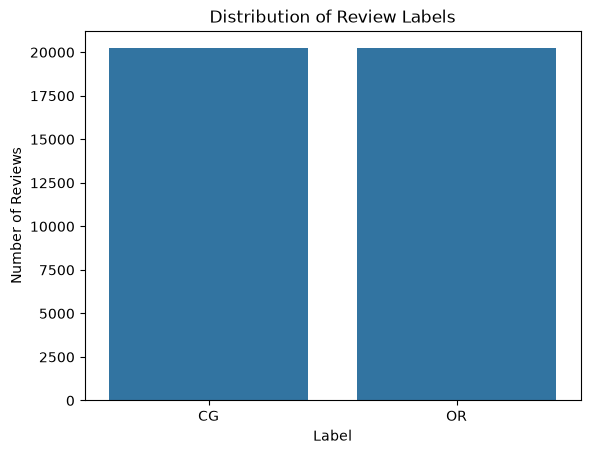

In [15]:
sns.countplot(data=df, x="label")

plt.title("Distribution of Review Labels")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")

plt.show()

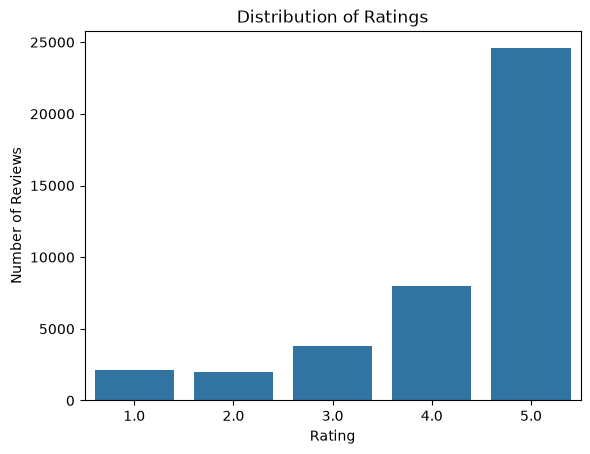

In [16]:
sns.countplot(data=df, x="rating")

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

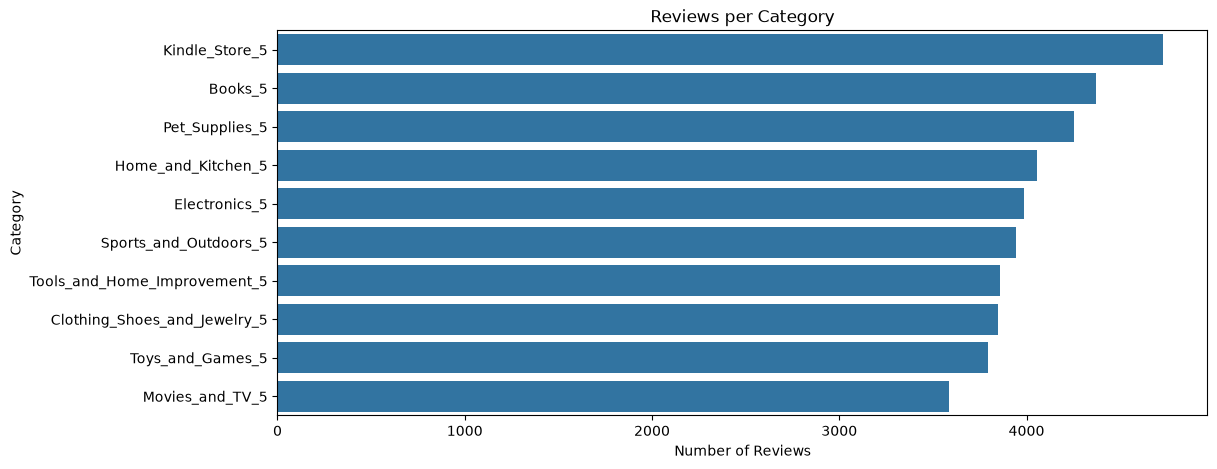

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Reviews per Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")

plt.show()

In [18]:
df[df["label"] == "CG"]["text_"].head(5)

0    Love this!  Well made, sturdy, and very comfor...
1    love it, a great upgrade from the original.  I...
2    This pillow saved my back. I love the look and...
3    Missing information on how to use it, but it i...
4    Very nice set. Good quality. We have had the s...
Name: text_, dtype: str

In [19]:
df[df["label"] == "OR"]["text_"].head(5)

55    These are just perfect, exactly what I was loo...
56    Such a great purchase can't beat it for the price
57    What can you say--- cheap and it works as inte...
58    These are so nice, sturdy, like the color choi...
59        It is nice bowl and have had a fast shipping!
Name: text_, dtype: str

In [20]:
df["review_length"] = df["text_"].apply(len)

In [21]:
df["review_length"].describe()

count    40432.000000
mean       351.271963
std        369.813570
min         24.000000
25%        107.000000
50%        198.000000
75%        439.000000
max       2827.000000
Name: review_length, dtype: float64

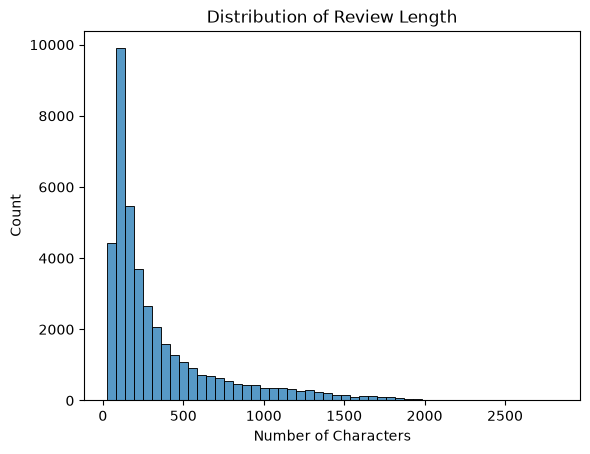

In [22]:
sns.histplot(df["review_length"], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Count")

plt.show()

In [23]:
df.groupby("label")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20216.0,305.573506,307.037430,24.0,96.0,174.0,383.0,1717.0
OR,20216.0,396.970419,418.428047,28.0,121.0,224.0,498.0,2827.0


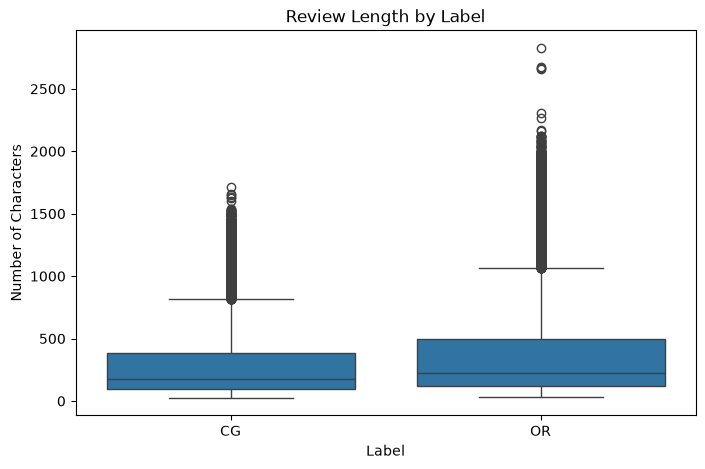

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="review_length"
)

plt.title("Review Length by Label")
plt.xlabel("Label")
plt.ylabel("Number of Characters")

plt.show()

In [25]:
df["label_name"] = df["label"].map({
    "OR": "Real",
    "CG": "Fake"
})

In [26]:
df["word_count"] = df["text_"].apply(lambda x: len(x.split()))

In [27]:
df.groupby("label_name")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Fake,20216.0,61.288237,61.799015,1.0,19.0,35.0,77.0,318.0
Real,20216.0,73.642610,76.078420,5.0,23.0,42.0,93.0,373.0


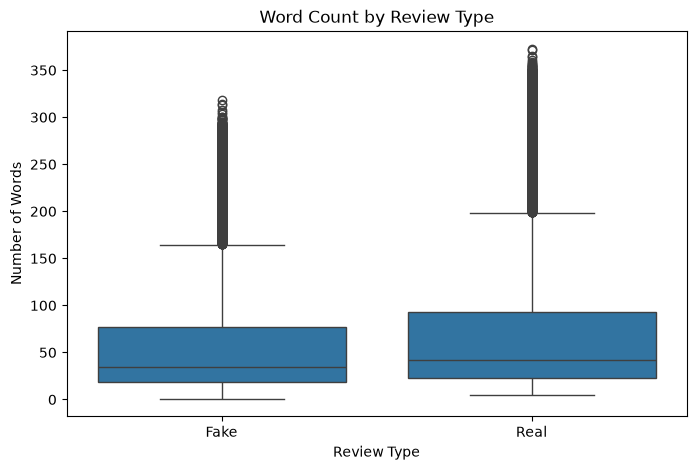

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label_name",
    y="word_count"
)

plt.title("Word Count by Review Type")
plt.xlabel("Review Type")
plt.ylabel("Number of Words")

plt.show()

In [29]:
from wordcloud import WordCloud

In [30]:
fake_text = " ".join(df[df["label_name"] == "Fake"]["text_"])

In [31]:
real_text = " ".join(df[df["label_name"] == "Real"]["text_"])

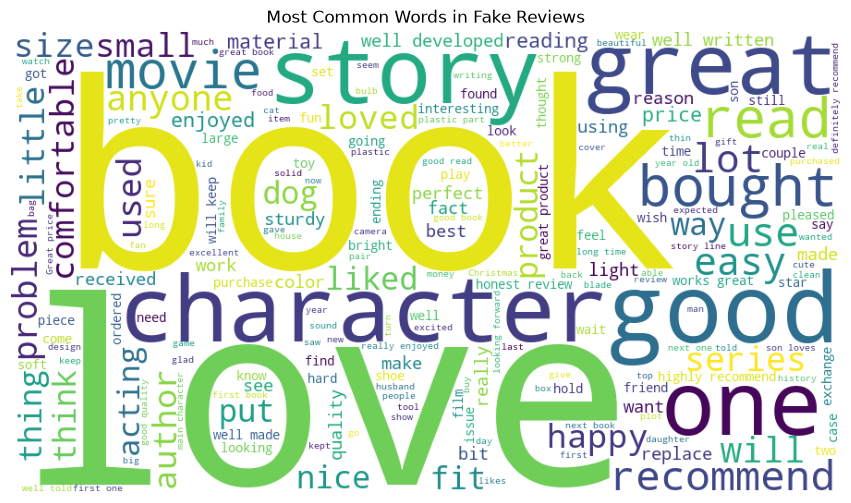

In [32]:
fake_wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(fake_wc)
plt.axis("off")
plt.title("Most Common Words in Fake Reviews")
plt.show()

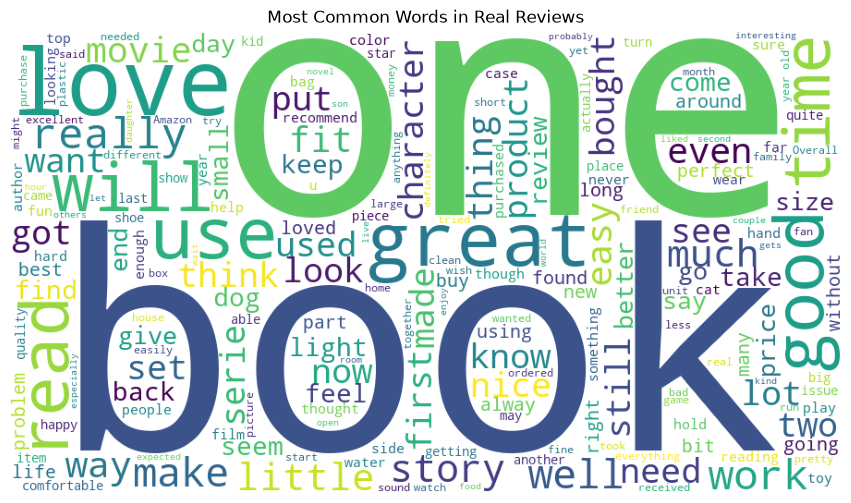

In [33]:
real_wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(real_wc)
plt.axis("off")
plt.title("Most Common Words in Real Reviews")
plt.show()

In [34]:
X = df["text_"]
y = df["label_name"]

## Data Preparation
Split the dataset into training and testing sets and prepare the text representation using TF-IDF.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

## Baseline Models
We begin with simple machine learning models that provide a baseline for comparison.

In [37]:
nb_model.fit(X_train, y_train)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier', MultinomialNB())])

In [38]:
type(nb_model)

sklearn.pipeline.Pipeline

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8404847285767281
              precision    recall  f1-score   support

        Fake       0.80      0.91      0.85      4044
        Real       0.90      0.77      0.83      4043

    accuracy                           0.84      8087
   macro avg       0.85      0.84      0.84      8087
weighted avg       0.85      0.84      0.84      8087



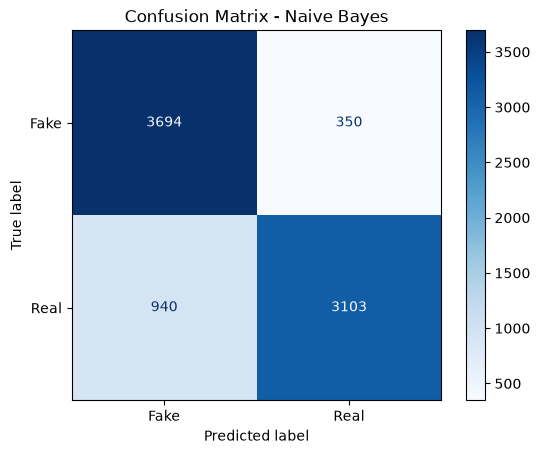

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [44]:
lr_model.fit(X_train, y_train)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [46]:
y_pred_lr = lr_model.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8659577099047855
              precision    recall  f1-score   support

        Fake       0.88      0.85      0.86      4044
        Real       0.85      0.88      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



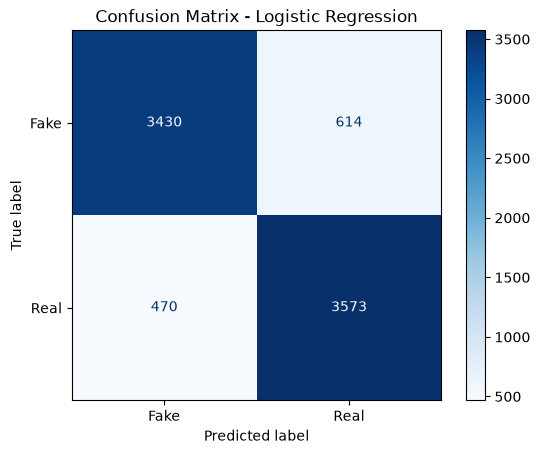

In [48]:
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
from sklearn import set_config
set_config(display="text")

In [49]:
from sklearn.svm import LinearSVC

In [50]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", LinearSVC(random_state=42))
])

In [51]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier', LinearSVC(random_state=42))])

In [52]:
y_pred_svm = svm_model.predict(X_test)

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8718931618647212
              precision    recall  f1-score   support

        Fake       0.87      0.88      0.87      4044
        Real       0.87      0.87      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



## Model Improvement
We improve the Linear SVM model by using bigrams and then perform hyperparameter tuning with GridSearchCV.

In [54]:
svm_bigram = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1,2)
        )
    ),
    (
        "classifier",
        LinearSVC(random_state=42)
    )
])

In [55]:
svm_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('classifier', LinearSVC(random_state=42))])

In [56]:
y_pred_bigram = svm_bigram.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred_bigram))
print(classification_report(y_test, y_pred_bigram))

Accuracy: 0.8994682824285891
              precision    recall  f1-score   support

        Fake       0.90      0.89      0.90      4044
        Real       0.90      0.90      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1,2],
    "classifier__C": [0.5,1,2]
}

In [60]:
grid = GridSearchCV(
    svm_bigram,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [61]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(ngram_range=(1, 2),
                                                        stop_words='english')),
                                       ('classifier',
                                        LinearSVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.5, 1, 2], 'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy')

In [62]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'classifier__C': 1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best Cross Validation Accuracy:
0.9016231256763024


In [63]:
import joblib

In [64]:
best_model = grid.best_estimator_

In [65]:
joblib.dump(best_model, "../models/best_fake_review_model.pkl")

['../models/best_fake_review_model.pkl']

In [66]:
loaded_model = joblib.load("../models/best_fake_review_model.pkl")

In [67]:
loaded_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier', LinearSVC(C=1, random_state=42))])

In [68]:
test_review = ["This product is amazing. It works perfectly and I highly recommend it."]

loaded_model.predict(test_review)

array(['Real'], dtype=object)

In [69]:
test_review = ["I bought this a month ago. At first it worked well, but after two weeks the quality started to drop."]

loaded_model.predict(test_review)

array(['Real'], dtype=object)

In [70]:
test_review = ["This is the best product ever. Amazing quality, perfect design, everyone should buy it now. Highly recommended, five stars!"]

loaded_model.predict(test_review)

array(['Real'], dtype=object)

In [71]:
test_reviews = [
    "This is the best product ever. Amazing quality, perfect design, everyone should buy it now. Highly recommended, five stars!",
    "I bought this last month for my kitchen. It arrived on time, but the handle feels weaker than I expected.",
    "Excellent excellent excellent product. Perfect item. Great purchase. I recommend it to everyone."
]

loaded_model.predict(test_reviews)

array(['Real', 'Real', 'Fake'], dtype=object)

## Final Deployment Model
The final version of the model was calibrated to provide confidence scores for deployment in the Streamlit application.

In [72]:
from sklearn.calibration import CalibratedClassifierCV

In [74]:
svm_confidence_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "classifier",
        CalibratedClassifierCV(
            LinearSVC(C=1, random_state=42),
            cv=3
        )
    )
])

In [75]:
svm_confidence_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(C=1,
                                                            random_state=42)))])

In [76]:
y_pred_conf = svm_confidence_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_conf))
print(classification_report(y_test, y_pred_conf))

Accuracy: 0.901694076913565
              precision    recall  f1-score   support

        Fake       0.91      0.90      0.90      4044
        Real       0.90      0.91      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



In [77]:
best_model = svm_confidence_model

joblib.dump(best_model, "../models/best_fake_review_model.pkl")

['../models/best_fake_review_model.pkl']

## Model Comparison

The following table summarizes the performance of all evaluated models. The final model achieved the highest accuracy and was selected for deployment in the Streamlit application.

In [ ]:
import pandas as pd

results = pd.DataFrame({


    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM",
        "Linear SVM + Bigrams",
        "Linear SVM + GridSearch",
        "Final Model (Calibrated SVM)"
    ],
    "Accuracy": [
        0.8405,
        0.8660,
        0.8719,
        0.8995,
        0.9016,
        0.9017
    ]
})

results = results.sort_values("Accuracy", ascending=False)

results

,Model,Accuracy
5,Final Model (Calibrated SVM),0.9017
4,Linear SVM + GridSearch,0.9016
3,Linear SVM + Bigrams,0.8995
2,Linear SVM,0.8719
1,Logistic Regression,0.8660
0,Naive Bayes,0.8405


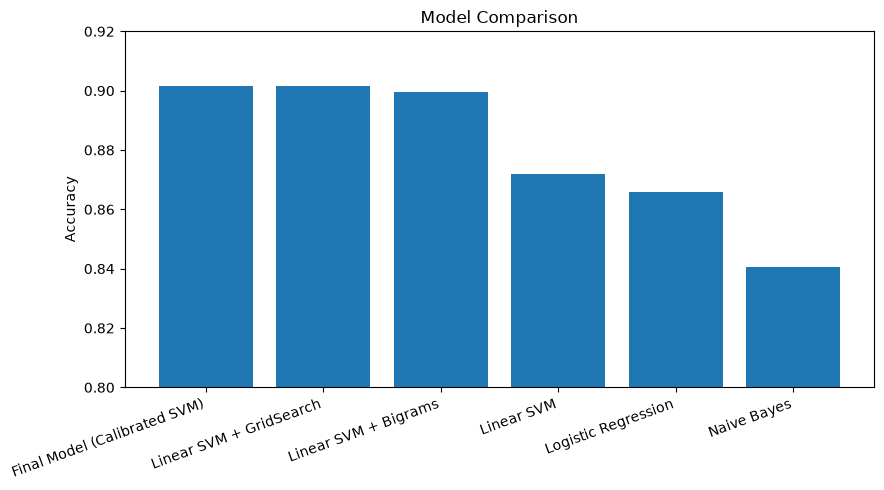

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.bar(results["Model"], results["Accuracy"])

plt.xticks(rotation=20, ha="right")

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.ylim(0.80, 0.92)

plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()